<a href="https://colab.research.google.com/github/KV-DHEERAJKUMAR/Attention-Driven-Network-Intrusion-Detection-A-Transformer-Approach-with-Synthetic-NSL-KDD-Data/blob/main/Attention_Driven_Network_Intrusion_Detection_A_Transformer_Approach_with_Synthetic_NSL_KDD_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 01 | Loss: 0.1343 | Train: 98.90% | Test: 98.89%
Epoch 02 | Loss: 0.1181 | Train: 98.99% | Test: 98.90%
Epoch 03 | Loss: 0.1178 | Train: 99.00% | Test: 98.90%
Epoch 04 | Loss: 0.1179 | Train: 99.00% | Test: 98.90%
Epoch 05 | Loss: 0.1175 | Train: 98.99% | Test: 98.90%
Epoch 06 | Loss: 0.1173 | Train: 99.00% | Test: 98.89%
Epoch 07 | Loss: 0.1171 | Train: 99.00% | Test: 98.88%
Epoch 08 | Loss: 0.1171 | Train: 99.00% | Test: 98.90%
Epoch 09 | Loss: 0.1169 | Train: 99.01% | Test: 98.90%
Epoch 10 | Loss: 0.1167 | Train: 99.00% | Test: 98.89%
Epoch 11 | Loss: 0.1167 | Train: 99.00% | Test: 98.88%
Epoch 12 | Loss: 0.1168 | Train: 99.00% | Test: 98.90%
Epoch 13 | Loss: 0.1164 | Train: 99.00% | Test: 98.90%
Epoch 14 | Loss: 0.1164 | Train: 99.00% | Test: 98.90%
Epoch 15 | Loss: 0.1165 | Train: 99.01% | Test: 98.89%
Epoch 16 | Loss: 0.1165 | Train: 99.00% | Test: 98.90%
Epoch 17 | Loss: 0.1163 | Train: 99.01% | Test: 98.88%
Epoch 18 | Loss: 0.1162 | Train: 99.00% | Test: 98.90%
Epoch 19 |

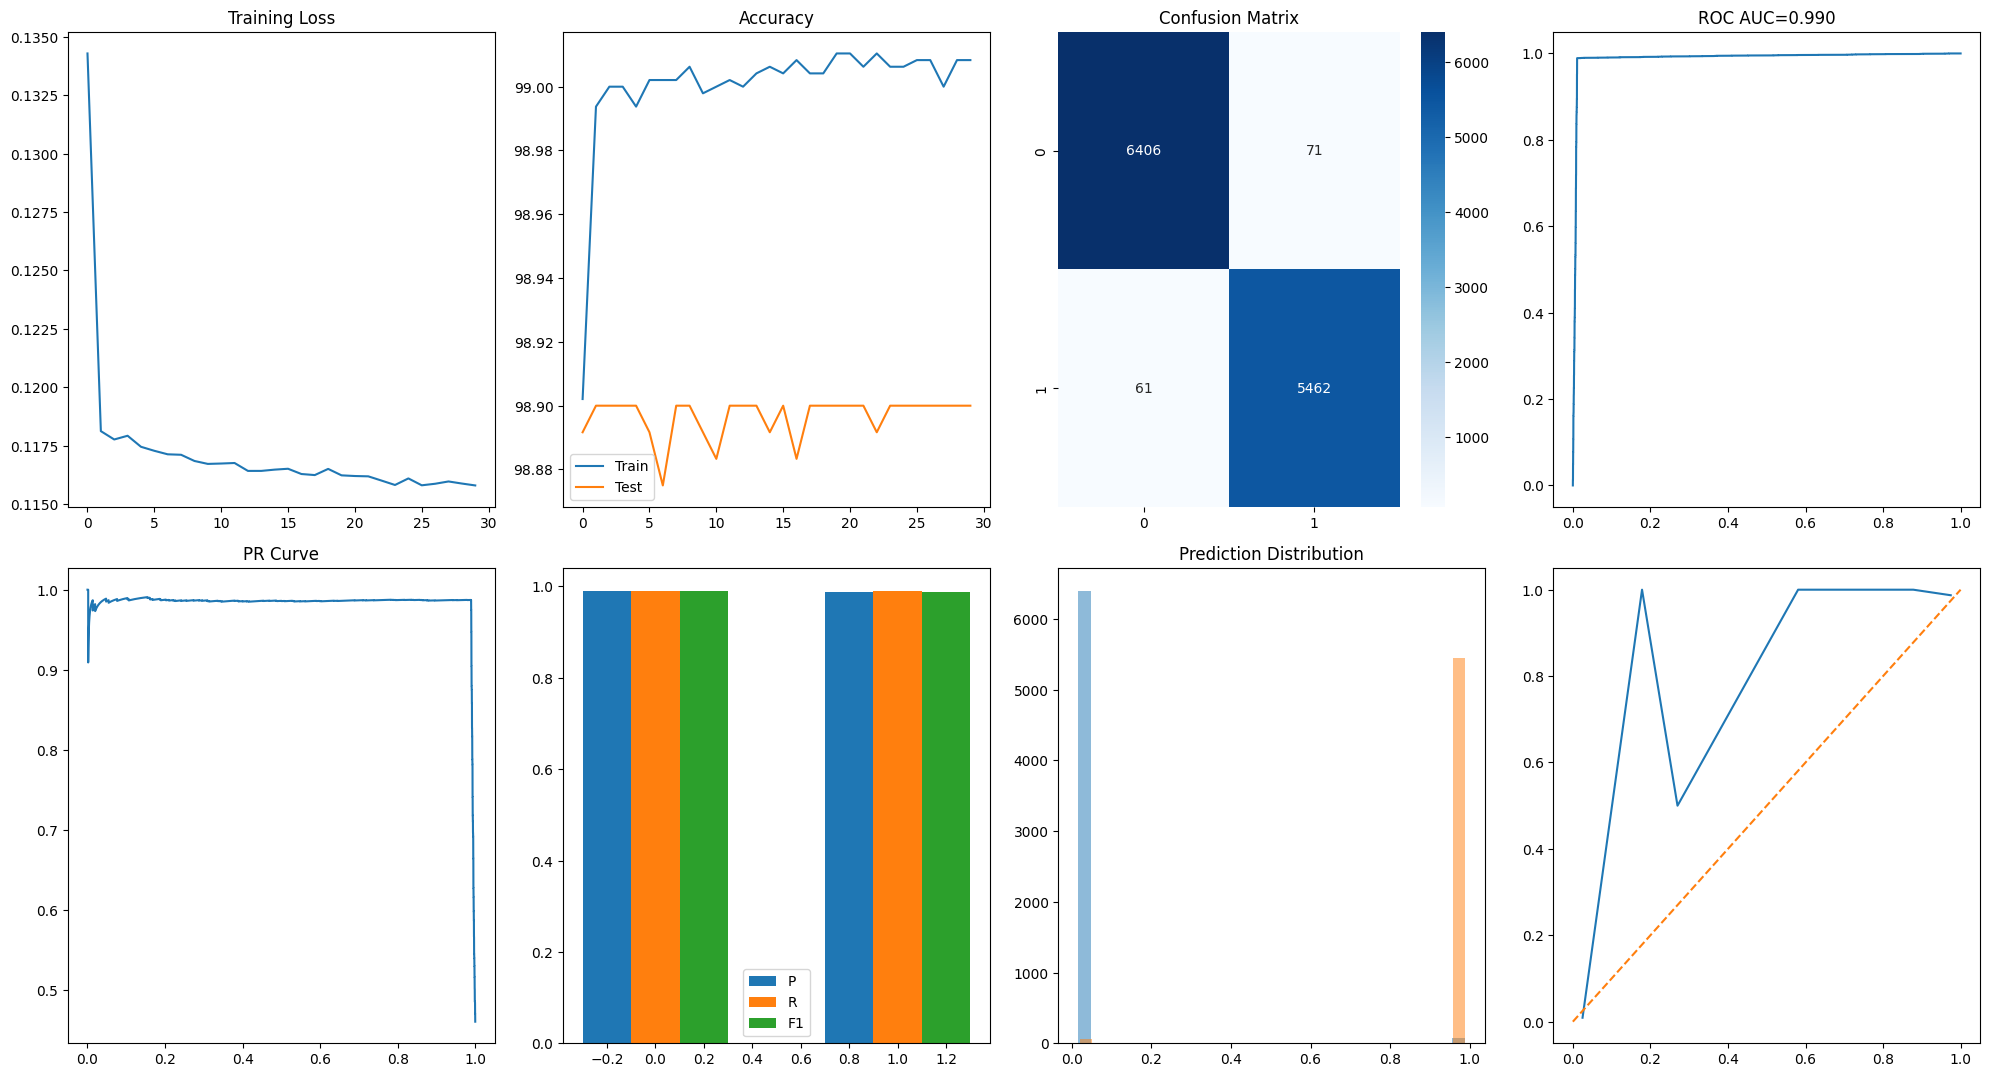

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_recall_curve, precision_score, recall_score, f1_score
from sklearn.calibration import calibration_curve

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ============================================
# DATA GENERATION
# ============================================

def generate_data(n_samples=60000):
    n_attack = int(n_samples * 0.46)
    n_normal = n_samples - n_attack

    data = {}

    data['src_bytes'] = np.concatenate([
        np.random.normal(650, 180, n_normal),
        np.random.normal(1150, 180, n_attack)
    ])

    data['dst_bytes'] = np.concatenate([
        np.random.normal(700, 150, n_normal),
        np.random.normal(450, 120, n_attack)
    ])

    data['count'] = np.concatenate([
        np.random.poisson(8, n_normal),
        np.random.poisson(22, n_attack)
    ])

    data['serror_rate'] = np.concatenate([
        np.random.beta(1, 15, n_normal),
        np.random.beta(7, 3, n_attack)
    ])

    df = pd.DataFrame(data)
    labels = np.concatenate([np.zeros(n_normal), np.ones(n_attack)])

    # small noise
    noise_idx = np.random.choice(len(df), int(len(df)*0.01), replace=False)
    labels[noise_idx] = 1 - labels[noise_idx]

    df['label'] = labels
    return df

df = generate_data()

# ============================================
# SPLIT
# ============================================

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================================
# SCALE
# ============================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# slight noise for realism
X_train += np.random.normal(0, 0.03, X_train.shape)

# ============================================
# MODEL
# ============================================

class Model(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model = Model(X_train.shape[1])

# ============================================
# TRAIN SETUP
# ============================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train.values)
y_test_t = torch.LongTensor(y_test.values)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

criterion = nn.CrossEntropyLoss(label_smoothing=0.03)
optimizer = optim.Adam(model.parameters(), lr=0.0004)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

# tracking
train_losses = []
train_accs = []
test_accs = []

# ============================================
# TRAINING
# ============================================

num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    correct, total, loss_sum = 0, 0, 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(Xb)

        # mild delay (not aggressive)
        if epoch < 3:
            outputs = outputs / 1.5

        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        pred = outputs.argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    avg_loss = loss_sum / len(train_loader)
    train_acc = 100 * correct / total

    # evaluation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            outputs = model(Xb)
            pred = outputs.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)

    test_acc = 100 * correct / total

    scheduler.step()

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")

# ============================================
# FINAL PREDICTIONS
# ============================================

y_pred = []
all_probs = []

model.eval()
with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(device)
        out = model(Xb)
        probs = torch.softmax(out, dim=1)
        y_pred.extend(out.argmax(1).cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_pred = np.array(y_pred)
all_probs = np.array(all_probs)
y_test_np = np.array(y_test)

acc = accuracy_score(y_test_np, y_pred)
print(f"\n✅ Final Accuracy: {acc*100:.2f}%")

# ============================================
# VISUALIZATION
# ============================================

plt.figure(figsize=(20,16))

# Loss
plt.subplot(3,4,1)
plt.plot(train_losses)
plt.title("Training Loss")

# Accuracy
plt.subplot(3,4,2)
plt.plot(train_accs, label="Train")
plt.plot(test_accs, label="Test")
plt.legend()
plt.title("Accuracy")

# Confusion Matrix
plt.subplot(3,4,3)
cm = confusion_matrix(y_test_np, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")

# ROC
plt.subplot(3,4,4)
fpr, tpr, _ = roc_curve(y_test_np, all_probs[:,1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.title(f"ROC AUC={roc_auc:.3f}")

# PR Curve
plt.subplot(3,4,5)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_np, all_probs[:,1])
plt.plot(recall_curve, precision_curve)
plt.title("PR Curve")

# Class metrics
plt.subplot(3,4,6)
precision = precision_score(y_test_np, y_pred, average=None)
recall = recall_score(y_test_np, y_pred, average=None)
f1 = f1_score(y_test_np, y_pred, average=None)
x = np.arange(2)
plt.bar(x-0.2, precision, 0.2, label='P')
plt.bar(x, recall, 0.2, label='R')
plt.bar(x+0.2, f1, 0.2, label='F1')
plt.legend()

# Prediction distribution
plt.subplot(3,4,7)
plt.hist(all_probs[y_test_np==0,1], bins=30, alpha=0.5)
plt.hist(all_probs[y_test_np==1,1], bins=30, alpha=0.5)
plt.title("Prediction Distribution")

# Calibration
plt.subplot(3,4,8)
prob_true, prob_pred = calibration_curve(y_test_np, all_probs[:,1], n_bins=10)
plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1],'--')

plt.tight_layout()
plt.savefig("results.png", dpi=300)
plt.show()

In [ ]:

from sklearn.metrics import classification_report

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    y_test_np,
    y_pred,
    target_names=["Normal", "Attack"],
    digits=4
))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.9906    0.9890    0.9898      6477
      Attack     0.9872    0.9890    0.9881      5523

    accuracy                         0.9890     12000
   macro avg     0.9889    0.9890    0.9889     12000
weighted avg     0.9890    0.9890    0.9890     12000

